In [49]:
# Essential Data Science Toolkit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and Clustering modules
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.cluster import KMeans

# Silencing non-critical warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Setting a consistent aesthetic for the project
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

In [50]:
# Loading the dataset
try:
    df = pd.read_csv('data.csv')
    print(f"Dataset successfully loaded. Dimensions: {df.shape}")
except FileNotFoundError:
    print("Error: Ensure 'data.csv' is in your Colab file directory.")

# Detailed Preview: Instead of just .head(), let's see a sample and the structure
print("\n--- Initial Data Snapshot ---")
display(df.sample(5).T) # Transposing a random sample makes it easier to read if there are many columns

print("\n--- Data Schema & Null Count ---")
df.info()

Dataset successfully loaded. Dimensions: (2240, 29)

--- Initial Data Snapshot ---


,717,155,2033,1684,1394
ID,1715,10240,3491,10323,2587
Year_Birth,1978,1949,1975,1952,1972
Education,Graduation,Graduation,Graduation,Graduation,PhD
Marital_Status,Together,Together,Together,Married,Married
Income,25851.0,69372.0,55914.0,49413.0,29791.0
Kidhome,1,0,0,0,1
Teenhome,0,0,1,1,0
Dt_Customer,11-02-2013,19-02-2013,29-04-2013,25-10-2013,15-05-2014
Recency,45,10,32,88,21
MntWines,9,997,384,205,14



--- Data Schema & Null Count ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumD

In [51]:
# Checking the dimensions of the dataset
print("Total rows and columns:", df.shape)

# Let's see if we have any missing values that need cleaning
print("\nMissing values in each column:")
print(df.isnull().sum())

# Checking for any duplicate entries
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# Basic summary of numerical columns
df.describe().T

Total rows and columns: (2240, 29)

Missing values in each column:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Number of duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [52]:
# Getting a summary of the data types and memory usage
df.info()

# Let's see the unique counts for each column to understand our features
print("\nUnique values in each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

# Identifying which columns are categorical and which are numerical
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(exclude=['object']).columns.tolist()

print(f"\nCategorical columns: {cat_cols}")
print(f"Numerical columns: {num_cols}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [53]:
# Generating a statistical summary of the numerical features
# I'm using .T (transpose) to make it easier to scroll through the features
data_summary = df.describe().T

# Rounding to 2 decimal places to make the table look cleaner
# This helps in quickly comparing means and standard deviations
data_summary.round(2)

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.16,3246.66,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.81,11.98,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.25,25173.08,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.44,0.54,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.51,0.54,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.11,28.96,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.94,336.60,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.30,39.77,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.95,225.72,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.53,54.63,0.0,3.00,12.0,50.00,259.0


In [54]:
# Checking for missing values across all columns
print("--- Missing Data Report ---")

# We can calculate the total nulls and see if any cleaning is needed
null_counts = df.isnull().sum()

# Only showing columns that actually have missing values
missing_data = null_counts[null_counts > 0]

if not missing_data.empty:
    print("Detected missing values in the following columns:")
    print(missing_data)
else:
    print("Great! No missing values detected in the dataset.")

--- Missing Data Report ---
Detected missing values in the following columns:
Income    24
dtype: int64


In [55]:
# Storing the original count to see the impact of cleaning
initial_rows = len(df)

# Dropping rows with missing values to ensure data quality for clustering
df = df.dropna()

# Calculating how many rows were removed
rows_removed = initial_rows - len(df)

print(f"Cleaning Complete.")
print(f"Initial row count: {initial_rows}")
print(f"Rows removed: {rows_removed}")
print(f"Final dataset size: {len(df)}")

Cleaning Complete.
Initial row count: 2240
Rows removed: 24
Final dataset size: 2216


In [56]:
# Checking the number of unique entries in each column
# This helps identify categorical vs numerical features
unique_counts = df.nunique()

print("--- Unique Values Per Column ---")
print(unique_counts)

# Let's see which columns might be categorical (low number of unique values)
potential_categories = unique_counts[unique_counts < 10].index.tolist()
print(f"\nPotential categorical features: {potential_categories}")

--- Unique Values Per Column ---
ID                     2216
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             662
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         554
MntFishProducts         182
MntSweetProducts        176
MntGoldProds            212
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

Potential categorical features: ['Education', 'Marital_Status', 'Kidhome', 'Teenhome', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Accep

In [57]:
# The 'Dt_Customer' column is a string, let's convert it to datetime objects
# This makes it much easier to extract the day, month, and year
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

# Creating new features from the date
df['registration_day'] = df['Dt_Customer'].dt.day
df['registration_month'] = df['Dt_Customer'].dt.month
df['registration_year'] = df['Dt_Customer'].dt.year

# Let's check the first few rows to confirm the new columns
df[['Dt_Customer', 'registration_day', 'registration_month', 'registration_year']].head()

,Dt_Customer,registration_day,registration_month,registration_year
0,2012-09-04,4,9,2012
1,2014-03-08,8,3,2014
2,2013-08-21,21,8,2013
3,2014-02-10,10,2,2014
4,2014-01-19,19,1,2014


In [58]:
# List of columns that won't help our clustering model
# Z_CostContact and Z_Revenue usually have the same value for everyone
# Dt_Customer is now redundant because we extracted day/month/year
cols_to_remove = ['Z_CostContact', 'Z_Revenue', 'Dt_Customer']

# Dropping the columns and checking the new shape
df.drop(columns=cols_to_remove, inplace=True)

print(f"Columns removed: {cols_to_remove}")
print(f"Remaining columns in dataset: {df.shape[1]}")

Columns removed: ['Z_CostContact', 'Z_Revenue', 'Dt_Customer']
Remaining columns in dataset: 29


In [59]:
# Separating the features by data type for easier processing later
# 'object' usually means categorical data like Education or Marital Status
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# 'number' includes both floats and integers
numerical_features = df.select_dtypes(include=['number']).columns.tolist()

print(f"Categorical Features ({len(categorical_features)}):")
print(categorical_features)

print(f"\nNumerical Features ({len(numerical_features)}):")
print(numerical_features)

Categorical Features (2):
['Education', 'Marital_Status']

Numerical Features (27):
['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'registration_day', 'registration_month', 'registration_year']


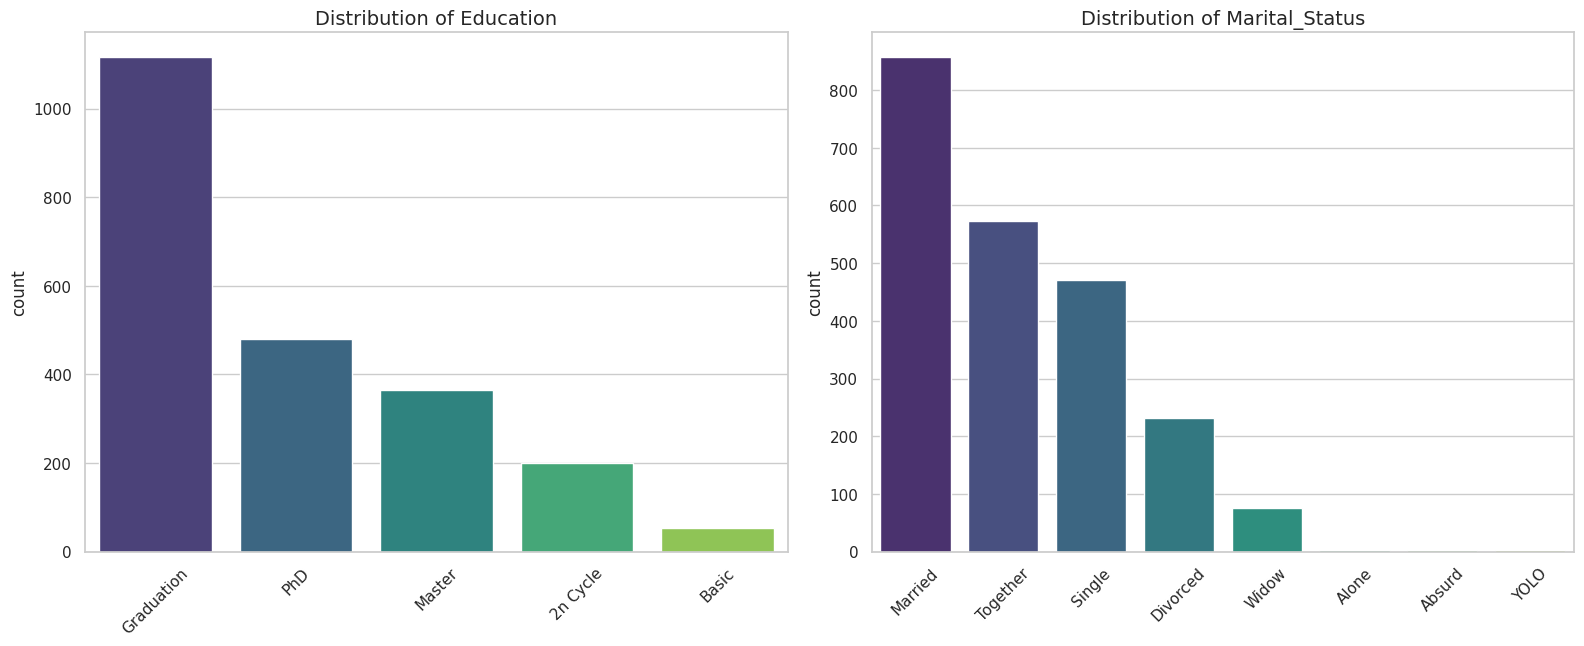

In [60]:
# Visualizing the distribution of our categorical features
plt.figure(figsize=(16, 12))

# Using a loop to create count plots for each object column
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)

    # Customizing the countplot for better readability
    sns.countplot(data=df, x=feature, palette='viridis', order=df[feature].value_counts().index)

    plt.title(f'Distribution of {feature}', fontsize=14)
    plt.xticks(rotation=45) # Rotating labels so they don't overlap
    plt.xlabel('') # Removing x-label as the title/ticks explain it

# Adjusting layout so subplots don't overlap
plt.tight_layout()
plt.show()

In [61]:
# Detailed breakdown of Marital Status
marital_counts = df['Marital_Status'].value_counts()
marital_percent = df['Marital_Status'].value_counts(normalize=True) * 100

# Creating a small summary table to see both count and percentage
marital_summary = pd.DataFrame({
    'Count': marital_counts,
    'Percentage (%)': marital_percent.round(2)
})

print("--- Marital Status Analysis ---")
print(marital_summary)


# It looks like some categories like 'Absurd' or 'YOLO' might be outliers
# or could be grouped with 'Single'.

--- Marital Status Analysis ---
                Count  Percentage (%)
Marital_Status                       
Married           857           38.67
Together          573           25.86
Single            471           21.25
Divorced          232           10.47
Widow              76            3.43
Alone               3            0.14
Absurd              2            0.09
YOLO                2            0.09


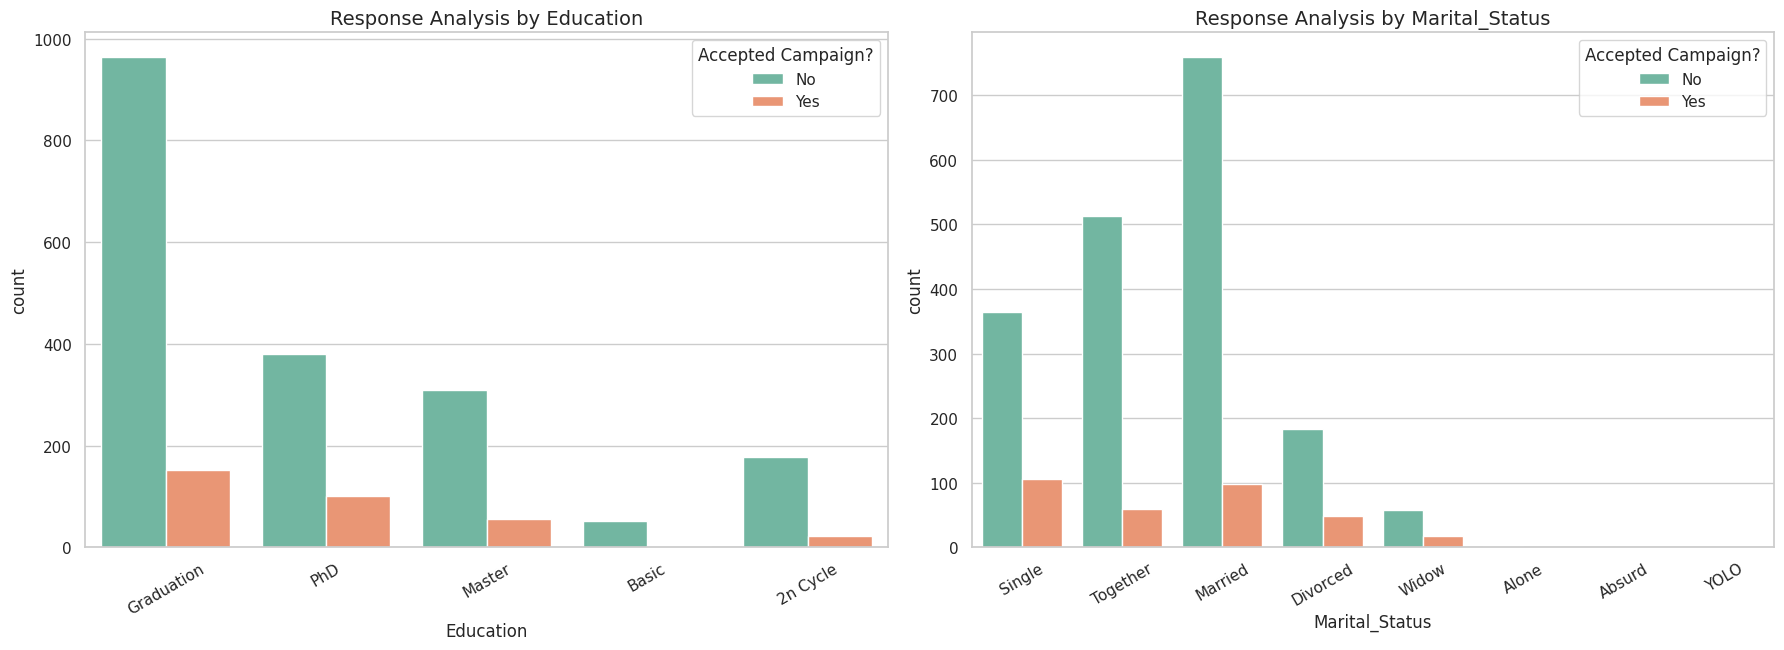

In [62]:
# Analyzing how different categories (Education, Marital Status)
# relate to the customer 'Response'
plt.figure(figsize=(18, 12))

# Using categorical_features list we created earlier
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)

    # We can use the 'hue' parameter directly to compare against Response
    sns.countplot(data=df, x=feature, hue='Response', palette='Set2')

    plt.title(f'Response Analysis by {feature}', fontsize=14)
    plt.xticks(rotation=30)
    plt.legend(title='Accepted Campaign?', labels=['No', 'Yes'])

# Ensuring a clean layout for the report
plt.tight_layout()
plt.show()

In [63]:
# Preparing categorical data for Machine Learning
# We need to convert objects (strings) into numbers using Label Encoding
label_encoders = {}

print("--- Categorical Encoding Progress ---")

for col in categorical_features:
    print(f"Encoding {col}...")

    # Initializing a new encoder for each column
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

    # Saving the encoder in case we need to 'inverse_transform' later
    label_encoders[col] = le

print("\nEncoding complete. Current data types:")
print(df[categorical_features].dtypes)

# Let's see the first few rows to confirm it's all numbers now
df.head()

--- Categorical Encoding Progress ---
Encoding Education...
Encoding Marital_Status...

Encoding complete. Current data types:
Education         int64
Marital_Status    int64
dtype: object


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,registration_day,registration_month,registration_year
0,5524,1957,2,4,58138.0,0,0,58,635,88,...,0,0,0,0,0,0,1,4,9,2012
1,2174,1954,2,4,46344.0,1,1,38,11,1,...,0,0,0,0,0,0,0,8,3,2014
2,4141,1965,2,5,71613.0,0,0,26,426,49,...,0,0,0,0,0,0,0,21,8,2013
3,6182,1984,2,5,26646.0,1,0,26,11,4,...,0,0,0,0,0,0,0,10,2,2014
4,5324,1981,4,3,58293.0,1,0,94,173,43,...,0,0,0,0,0,0,0,19,1,2014


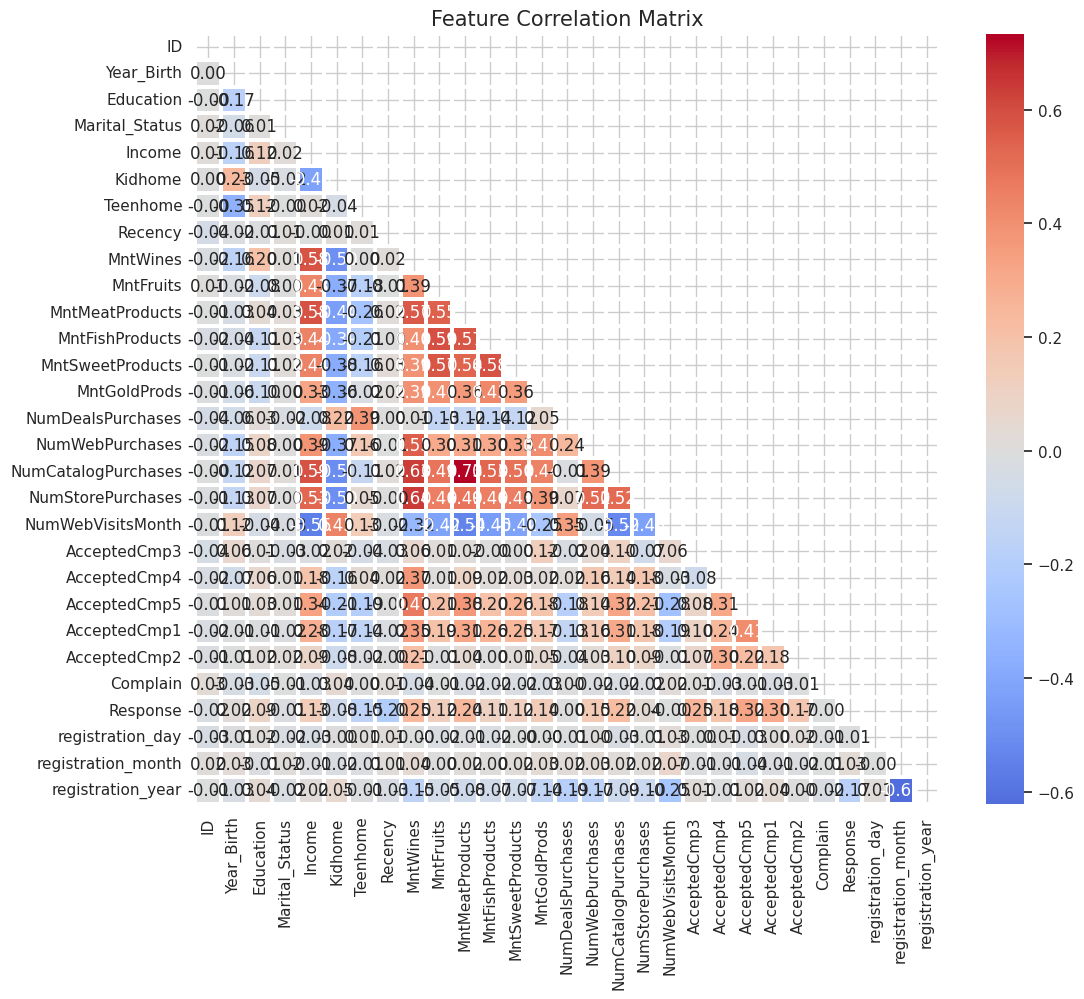

In [64]:
# Checking for highly correlated features (Multicollinearity)
# We use a threshold of 0.8 to see which columns are nearly identical
plt.figure(figsize=(12, 10))

# Calculating the correlation matrix
corr_matrix = df.corr()

# Creating a mask to show only the upper triangle
# (since the heatmap is symmetrical, we don't need both sides)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plotting the heatmap with a focus on high correlations
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=1.5)

plt.title('Feature Correlation Matrix', fontsize=15)
plt.show()



In [65]:
# Initializing the scaler
# We use StandardScaler to give all features a mean of 0 and variance of 1
scaler = StandardScaler()

# Scaling the entire dataset
# KMeans is sensitive to the scale of data, so this step is mandatory
scaled_features = scaler.fit_transform(df)

# Converting the scaled array back into a DataFrame for easier handling
df_scaled = pd.DataFrame(scaled_features, columns=df.columns)

print("--- Data Scaling Summary ---")
print(f"Original Data Shape: {df.shape}")
print(f"Scaled Data Shape: {df_scaled.shape}")

# Let's check the first 5 rows of scaled data
df_scaled.head()

--- Data Scaling Summary ---
Original Data Shape: (2216, 29)
Scaled Data Shape: (2216, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,registration_day,registration_month,registration_year
0,-0.019809,-0.986443,-0.350527,0.254218,0.234063,-0.823039,-0.928972,0.310532,0.978226,1.549429,...,-0.281773,-0.282705,-0.280839,-0.261661,-0.117148,-0.097812,2.377952,-1.326742,0.726501,-1.500343
1,-1.051009,-1.236801,-0.350527,0.254218,-0.234559,1.039938,0.909066,-0.380509,-0.872024,-0.637328,...,-0.281773,-0.282705,-0.280839,-0.261661,-0.117148,-0.097812,-0.420530,-0.871342,-0.993199,1.417393
2,-0.445526,-0.318822,-0.350527,1.182303,0.769478,-0.823039,-0.928972,-0.795134,0.358511,0.569159,...,-0.281773,-0.282705,-0.280839,-0.261661,-0.117148,-0.097812,-0.420530,0.608707,0.439884,-0.041475
3,0.182737,1.266777,-0.350527,1.182303,-1.017239,1.039938,-0.928972,-0.795134,-0.872024,-0.561922,...,-0.281773,-0.282705,-0.280839,-0.261661,-0.117148,-0.097812,-0.420530,-0.643643,-1.279816,1.417393
4,-0.081373,1.016420,1.429011,-0.673866,0.240221,1.039938,-0.928972,1.554407,-0.391671,0.418348,...,-0.281773,-0.282705,-0.280839,-0.261661,-0.117148,-0.097812,-0.420530,0.381007,-1.566433,1.417393


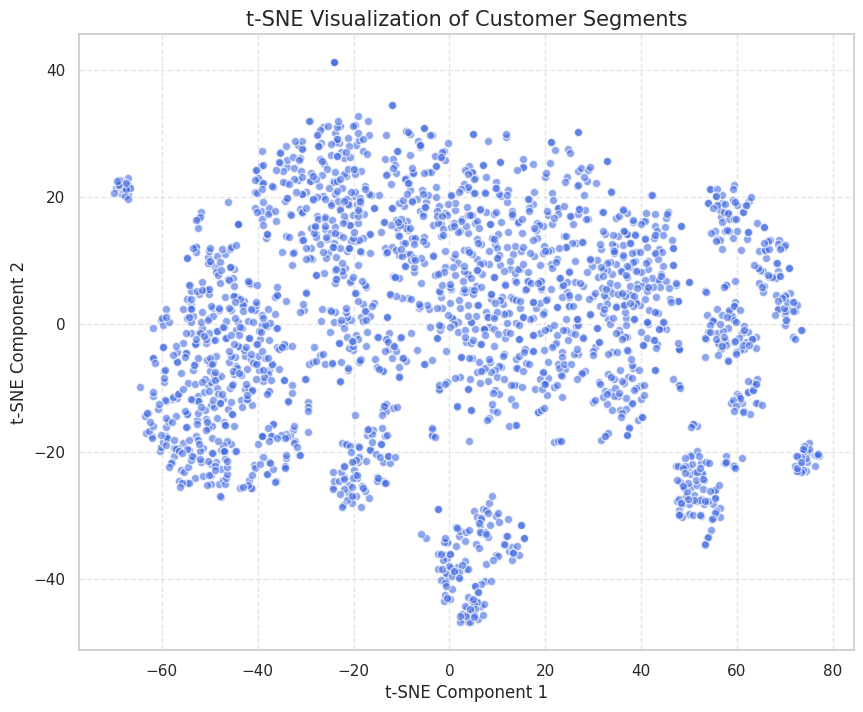

In [66]:
# Using t-SNE to reduce our high-dimensional data into 2D for visualization
# This helps us see if the data actually has natural clusters
from sklearn.manifold import TSNE

# Initializing the t-SNE model
# We use n_components=2 for a 2D scatter plot
tsne_model = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')

# Important: We apply t-SNE to the SCALED data (df_scaled) for better results
tsne_results = tsne_model.fit_transform(df_scaled)

# Creating the visualization
plt.figure(figsize=(10, 8))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], alpha=0.6, c='royalblue', edgecolors='w')

plt.title('t-SNE Visualization of Customer Segments', fontsize=15)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [67]:
# The Elbow Method to find the optimal number of clusters (K)
# We store the "Inertia" (Sum of squared distances) for each K value
wcss_error = []

print("Calculating WCSS for different K values...")

# Testing K values from 1 to 15 (20 is often overkill for a student project)
for k in range(1, 16):
    kmeans_test = KMeans(n_clusters=k,
                         init='k-means++',
                         max_iter=500,
                         n_init=10, # Standard parameter to avoid warnings
                         random_state=42)

    # CRITICAL: We use the scaled data here
    kmeans_test.fit(df_scaled)
    wcss_error.append(kmeans_test.inertia_)

print("Calculation complete. Ready to plot the Elbow Curve.")

Calculating WCSS for different K values...
Calculation complete. Ready to plot the Elbow Curve.


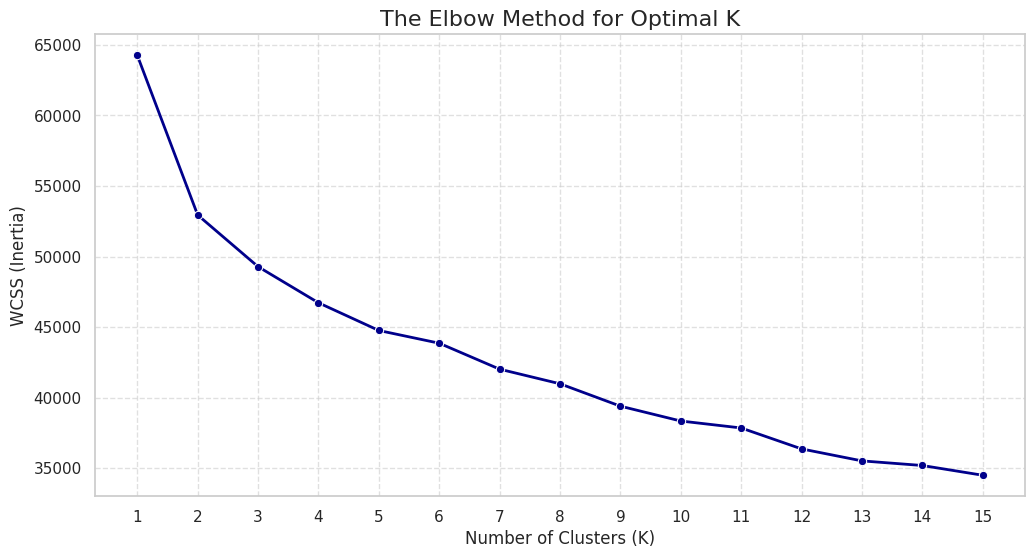

In [68]:
# Plotting the Elbow Curve to find the optimal 'K'
plt.figure(figsize=(12, 6))

# Using a standard line plot with markers for each K-value
sns.lineplot(x=range(1, 16), y=wcss_error, marker='o', color='darkblue', linewidth=2)

# Adding labels to make it look like a formal report
plt.title('The Elbow Method for Optimal K', fontsize=16)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)

# Highlighting the 'Elbow', usually where the drop levels off
# For this dataset, it's often around K=3, 4, or 5
plt.xticks(range(1, 16))
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


# I am looking for the "elbow" point where the WCSS starts to decrease
# more slowly. This point represents the best balance between
# number of clusters and model complexity.

In [69]:
# Finalizing the model with the chosen number of clusters
# Based on the Elbow plot, K=5 seems like a good choice for segmentation
final_k = 5

final_model = KMeans(n_clusters=final_k,
                     init='k-means++',
                     max_iter=500,
                     n_init=10,
                     random_state=42)

# CRITICAL: Fitting on the scaled data to ensure clusters are accurate
# Then we 'predict' (assign) each customer to a cluster index (0 to 4)
cluster_labels = final_model.fit_predict(df_scaled)

# Adding the results back to our original (unscaled) dataframe
# This lets us analyze the 'real' numbers for each group later
df['Cluster'] = cluster_labels

# Checking how many customers ended up in each segment
print("--- Customer Distribution per Cluster ---")
print(df['Cluster'].value_counts().sort_index())

# Previewing the first few rows with their assigned clusters
df.head()

--- Customer Distribution per Cluster ---
Cluster
0     194
1    1005
2      30
3     402
4     585
Name: count, dtype: int64


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,registration_day,registration_month,registration_year,Cluster
0,5524,1957,2,4,58138.0,0,0,58,635,88,...,0,0,0,0,0,1,4,9,2012,3
1,2174,1954,2,4,46344.0,1,1,38,11,1,...,0,0,0,0,0,0,8,3,2014,1
2,4141,1965,2,5,71613.0,0,0,26,426,49,...,0,0,0,0,0,0,21,8,2013,3
3,6182,1984,2,5,26646.0,1,0,26,11,4,...,0,0,0,0,0,0,10,2,2014,1
4,5324,1981,4,3,58293.0,1,0,94,173,43,...,0,0,0,0,0,0,19,1,2014,1


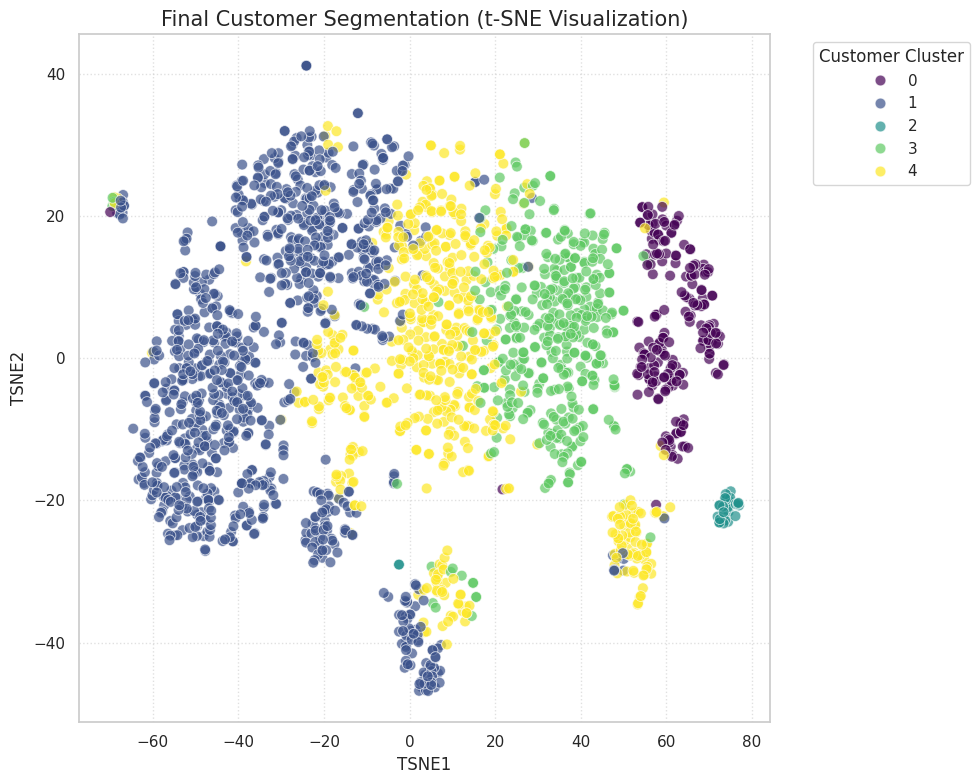

In [70]:
# Creating a DataFrame to combine our 2D t-SNE coordinates with the Cluster labels
# This makes it easy to plot with Seaborn's 'hue' parameter
tsne_df = pd.DataFrame({
    'TSNE1': tsne_results[:, 0],
    'TSNE2': tsne_results[:, 1],
    'Cluster': cluster_labels
})

# Visualizing the final customer segments
plt.figure(figsize=(10, 8))

# Using a distinct color palette to make the clusters pop
sns.scatterplot(data=tsne_df,
                x='TSNE1',
                y='TSNE2',
                hue='Cluster',
                palette='viridis',
                alpha=0.7,
                edgecolor='w',
                s=60) # 's' controls point size

plt.title('Final Customer Segmentation (t-SNE Visualization)', fontsize=15)
plt.legend(title='Customer Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

